第一部分：深度学习CNN模型实现

1.1 环境准备与数据加载

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子确保可复现性
torch.manual_seed(42)
np.random.seed(42)

# 设置绘图样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 检查GPU可用性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if torch.cuda.is_available():
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
    print(f"显存: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

使用设备: cuda
GPU型号: NVIDIA GeForce RTX 5090
显存: 31.84 GB


中文字体显示

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import os
import numpy as np

# 方法1: 设置字体为支持中文的字体
def setup_chinese_font():
    """
    设置中文字体支持
    """
    # 获取系统中可用的中文字体
    import matplotlib.font_manager as fm

    # 列出所有字体
    font_list = fm.findSystemFonts()
    chinese_fonts = []

    # 常见的中文字体名称
    chinese_font_names = [
        'SimHei',        # 黑体
        'Microsoft YaHei',  # 微软雅黑
        'SimSun',        # 宋体
        'KaiTi',         # 楷体
        'FangSong',      # 仿宋
        'STXihei',       # 华文细黑
        'STSong',        # 华文宋体
        'STKaiti',       # 华文楷体
        'STFangsong',    # 华文仿宋
        'DengXian',      # 等线
        'YouYuan',       # 幼圆
        'LiSu',          # 隶书
        'NSimSun',       # 新宋体
    ]

    # 查找系统中存在的中文字体
    available_fonts = []
    for font_path in font_list:
        try:
            font = fm.FontProperties(fname=font_path)
            font_name = font.get_name()

            # 检查是否是中文字体
            for chinese_font in chinese_font_names:
                if chinese_font in font_name:
                    available_fonts.append((chinese_font, font_path))
                    break
        except:
            continue

    # 设置字体
    if available_fonts:
        # 按优先级选择字体
        for preferred_font in ['Microsoft YaHei', 'SimHei', 'SimSun']:
            for font_name, font_path in available_fonts:
                if preferred_font in font_name:
                    # 设置matplotlib字体
                    matplotlib.font_manager.fontManager.addfont(font_path)
                    font_prop = matplotlib.font_manager.FontProperties(fname=font_path)
                    font_name = font_prop.get_name()

                    # 设置全局字体
                    plt.rcParams['font.sans-serif'] = [font_name]
                    plt.rcParams['axes.unicode_minus'] = False

                    # 设置seaborn字体
                    sns.set(font=font_name)

                    print(f"✓ 已设置中文字体: {font_name}")
                    return True

        # 如果没找到优先字体，使用第一个可用的
        font_name, font_path = available_fonts[0]
        matplotlib.font_manager.fontManager.addfont(font_path)
        font_prop = matplotlib.font_manager.FontProperties(fname=font_path)
        font_name = font_prop.get_name()

        plt.rcParams['font.sans-serif'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set(font=font_name)

        print(f"✓ 已设置中文字体: {font_name}")
        return True
    else:
        print("⚠ 未找到系统中文字体，将使用默认字体")
        return False

# 调用字体设置
setup_chinese_font()

✓ 已设置中文字体: Microsoft YaHei


True

1.2 数据准备

In [2]:
# 定义数据转换
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST的均值和标准差
])

# 加载完整MNIST数据集
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# 划分训练集和验证集
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

print(f"训练集大小: {len(train_dataset)}")
print(f"验证集大小: {len(val_dataset)}")
print(f"测试集大小: {len(test_dataset)}")

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

训练集大小: 48000
验证集大小: 12000
测试集大小: 10000


1.3 简单CNN模型定义

In [3]:
class SimpleCNN(nn.Module):
    """
    简单的卷积神经网络模型
    结构: Conv2d -> ReLU -> MaxPool2d -> Conv2d -> ReLU -> MaxPool2d -> Linear -> Dropout -> Linear
    """
    def __init__(self, dropout_rate=0.5):
        super(SimpleCNN, self).__init__()

        # 卷积层
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 28x28x1 -> 28x28x32
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 14x14x32 -> 14x14x64

        # 池化层
        self.pool = nn.MaxPool2d(2, 2)  # 尺寸减半

        # 全连接层
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # 7x7x64 -> 128
        self.fc2 = nn.Linear(128, 10)  # 128 -> 10 (数字0-9)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)

        # 参数初始化
        self._initialize_weights()

    def _initialize_weights(self):
        """初始化网络权重"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # 第一层卷积
        x = self.pool(F.relu(self.conv1(x)))  # 28x28 -> 14x14
        # 第二层卷积
        x = self.pool(F.relu(self.conv2(x)))  # 14x14 -> 7x7

        # 展平
        x = x.view(-1, 64 * 7 * 7)

        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# 创建模型实例
model = SimpleCNN(dropout_rate=0.5).to(device)
print("CNN模型结构:")
print(model)

# 计算参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n总参数量: {total_params:,}")
print(f"可训练参数量: {trainable_params:,}")

CNN模型结构:
SimpleCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

总参数量: 421,642
可训练参数量: 421,642


1.4 模型训练与评估

In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """训练一个epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (data, target) in enumerate(tqdm(dataloader, desc="训练")):
        data, target = data.to(device), target.to(device)

        # 清零梯度
        optimizer.zero_grad()

        # 前向传播
        outputs = model(data)
        loss = criterion(outputs, target)

        # 反向传播
        loss.backward()
        optimizer.step()

        # 统计
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    """验证模型"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in tqdm(dataloader, desc="验证"):
            data, target = data.to(device), target.to(device)
            outputs = model(data)
            loss = criterion(outputs, target)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001):
    """训练模型"""
    # 定义损失函数和优化器
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # 学习率调度器
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    # 记录训练历史
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }

    best_val_acc = 0.0
    best_model_state = None

    print("开始训练CNN模型...")
    print("="*60)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 40)

        # 训练
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # 验证
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        # 学习率调度
        scheduler.step(val_loss)

        # 保存最佳模型
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            print(f"保存最佳模型，验证准确率: {val_acc:.2f}%")

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        # 打印进度
        print(f"训练损失: {train_loss:.4f}, 训练准确率: {train_acc:.2f}%")
        print(f"验证损失: {val_loss:.4f}, 验证准确率: {val_acc:.2f}%")
        print(f"学习率: {optimizer.param_groups[0]['lr']:.6f}")

    # 加载最佳模型
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print("="*60)
    print(f"训练完成！最佳验证准确率: {best_val_acc:.2f}%")

    return model, history

# 训练模型
num_epochs = 10
trained_model, history = train_model(model, train_loader, val_loader, num_epochs=num_epochs, lr=0.001)

开始训练CNN模型...

Epoch 1/10
----------------------------------------


验证: 100%|██████████| 188/188 [00:02<00:00, 80.29it/s] 


保存最佳模型，验证准确率: 97.58%
训练损失: 0.2975, 训练准确率: 90.84%
验证损失: 0.0767, 验证准确率: 97.58%
学习率: 0.001000

Epoch 2/10
----------------------------------------


验证: 100%|██████████| 188/188 [00:02<00:00, 79.88it/s] 


保存最佳模型，验证准确率: 98.28%
训练损失: 0.0969, 训练准确率: 97.16%
验证损失: 0.0600, 验证准确率: 98.28%
学习率: 0.001000

Epoch 3/10
----------------------------------------


...

保存最佳模型，验证准确率: 99.03%
训练损失: 0.0328, 训练准确率: 98.96%
验证损失: 0.0374, 验证准确率: 99.03%
学习率: 0.001000

Epoch 9/10
----------------------------------------


验证: 100%|██████████| 188/188 [00:02<00:00, 77.45it/s] 


训练损失: 0.0314, 训练准确率: 99.03%
验证损失: 0.0392, 验证准确率: 98.83%
学习率: 0.000500

Epoch 10/10
----------------------------------------


验证: 100%|██████████| 188/188 [00:02<00:00, 76.63it/s] 

保存最佳模型，验证准确率: 99.20%
训练损失: 0.0183, 训练准确率: 99.42%
验证损失: 0.0366, 验证准确率: 99.20%
学习率: 0.000500
训练完成！最佳验证准确率: 99.20%


1.5 可视化训练过程

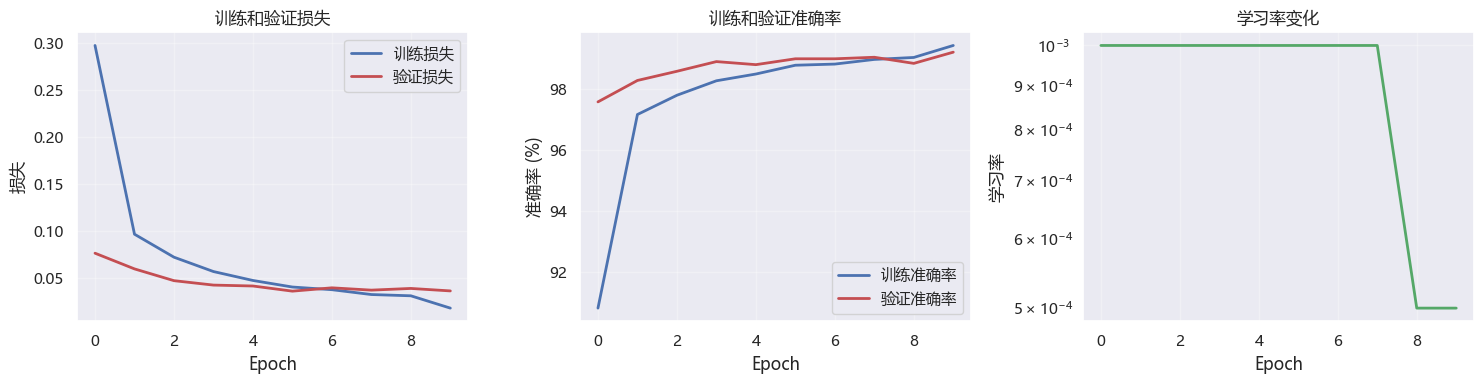

训练结果总结:
  最终训练损失: 0.0183
  最终训练准确率: 99.42%
  最终验证损失: 0.0366
  最终验证准确率: 99.20%
  过拟合程度: 0.22%


In [8]:
def plot_training_history(history):
    """可视化训练过程"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 损失曲线
    axes[0].plot(history['train_loss'], 'b-', label='训练损失', linewidth=2)
    axes[0].plot(history['val_loss'], 'r-', label='验证损失', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('损失')
    axes[0].set_title('训练和验证损失')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # 准确率曲线
    axes[1].plot(history['train_acc'], 'b-', label='训练准确率', linewidth=2)
    axes[1].plot(history['val_acc'], 'r-', label='验证准确率', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('准确率 (%)')
    axes[1].set_title('训练和验证准确率')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # 学习率曲线
    axes[2].plot(history['lr'], 'g-', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('学习率')
    axes[2].set_title('学习率变化')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_yscale('log')

    plt.tight_layout()
    plt.show()

    # 打印最终性能
    print("训练结果总结:")
    print(f"  最终训练损失: {history['train_loss'][-1]:.4f}")
    print(f"  最终训练准确率: {history['train_acc'][-1]:.2f}%")
    print(f"  最终验证损失: {history['val_loss'][-1]:.4f}")
    print(f"  最终验证准确率: {history['val_acc'][-1]:.2f}%")

    # 计算过拟合程度
    overfit_degree = (history['train_acc'][-1] - history['val_acc'][-1]) / history['train_acc'][-1] * 100
    print(f"  过拟合程度: {overfit_degree:.2f}%")

# 可视化训练历史
plot_training_history(history)

1.6 在测试集上评估

In [9]:
def evaluate_on_test(model, test_loader, device):
    """在测试集上评估模型"""
    model.eval()
    all_labels = []
    all_predictions = []
    all_probs = []

    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in tqdm(test_loader, desc="测试"):
            data, target = data.to(device), target.to(device)
            outputs = model(data)

            # 获取预测结果
            probs = F.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            # 统计
            total += target.size(0)
            correct += predicted.eq(target).sum().item()

            # 保存结果用于分析
            all_labels.extend(target.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    test_accuracy = 100. * correct / total

    print("="*60)
    print(f"测试集准确率: {test_accuracy:.2f}%")
    print(f"正确数: {correct}/{total}")
    print("="*60)

    return test_accuracy, np.array(all_labels), np.array(all_predictions), np.array(all_probs)

# 在测试集上评估
test_acc, test_labels, test_preds, test_probs = evaluate_on_test(trained_model, test_loader, device)

测试: 100%|██████████| 157/157 [00:02<00:00, 65.77it/s] 

测试集准确率: 99.24%
正确数: 9924/10000


1.7 混淆矩阵分析

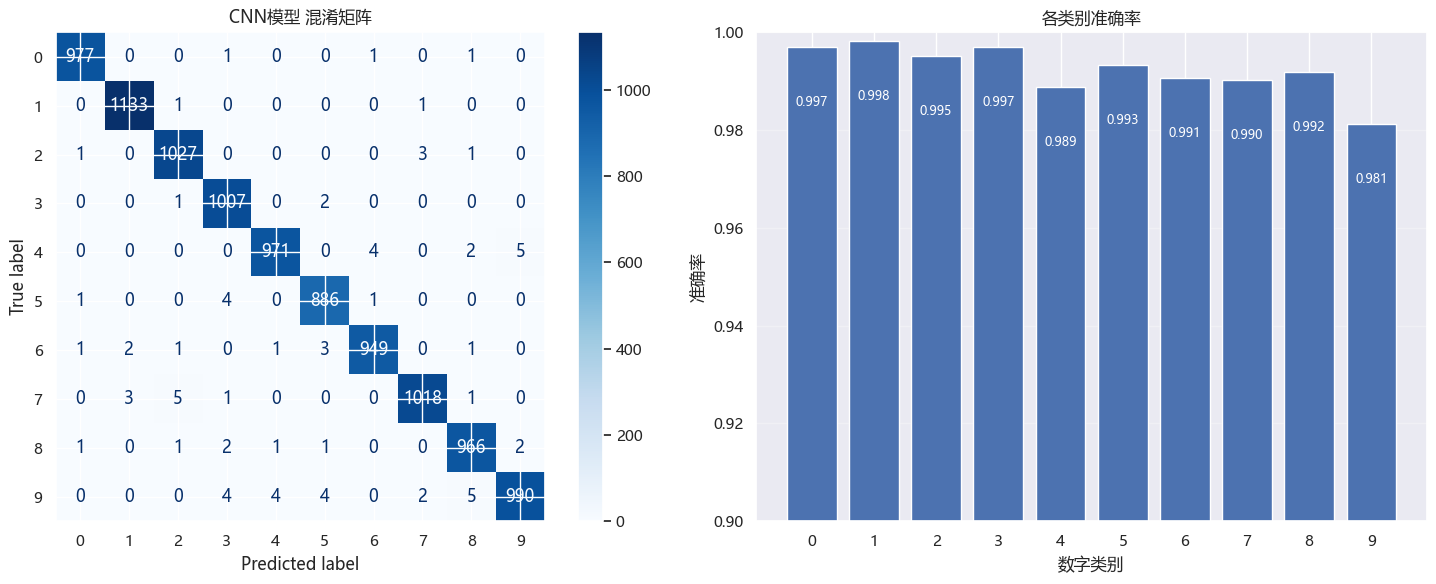


CNN模型 分类报告:
              precision    recall  f1-score   support

           0     0.9959    0.9969    0.9964       980
           1     0.9956    0.9982    0.9969      1135
           2     0.9913    0.9952    0.9932      1032
           3     0.9882    0.9970    0.9926      1010
           4     0.9939    0.9888    0.9913       982
           5     0.9888    0.9933    0.9911       892
           6     0.9937    0.9906    0.9922       958
           7     0.9941    0.9903    0.9922      1028
           8     0.9887    0.9918    0.9903       974
           9     0.9930    0.9812    0.9870      1009

    accuracy                         0.9924     10000
   macro avg     0.9923    0.9923    0.9923     10000
weighted avg     0.9924    0.9924    0.9924     10000


最难区分的类别对 (非对角线值最高):
  4 被误分为 9: 5次 (0.5%)
  7 被误分为 2: 5次 (0.5%)
  9 被误分为 8: 5次 (0.5%)
  4 被误分为 6: 4次 (0.4%)
  5 被误分为 3: 4次 (0.4%)


In [10]:
def plot_confusion_matrix_deep(y_true, y_pred, model_name="CNN模型"):
    """绘制深度学习模型的混淆矩阵"""
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)

    # 创建图形
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # 混淆矩阵热图
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title(f'{model_name} 混淆矩阵')

    # 各类别准确率
    class_accuracies = np.diag(cm) / cm.sum(axis=1)

    axes[1].bar(range(10), class_accuracies)
    axes[1].set_xlabel('数字类别')
    axes[1].set_ylabel('准确率')
    axes[1].set_title('各类别准确率')
    axes[1].set_xticks(range(10))
    axes[1].set_ylim([0.9, 1.0])
    axes[1].grid(True, alpha=0.3, axis='y')

    # 添加准确率标签
    for i, acc in enumerate(class_accuracies):
        axes[1].text(i, acc - 0.01, f'{acc:.3f}',
                    ha='center', va='top', fontsize=9, color='white')

    plt.tight_layout()
    plt.show()

    # 打印分类报告
    print(f"\n{model_name} 分类报告:")
    print(classification_report(y_true, y_pred, digits=4))

    # 找出最难区分的类别对
    print("\n最难区分的类别对 (非对角线值最高):")
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)

    max_errors = []
    for i in range(10):
        for j in range(10):
            if i != j and cm[i, j] > 0:
                max_errors.append((i, j, cm[i, j]))

    # 按错误数量排序
    max_errors.sort(key=lambda x: x[2], reverse=True)

    for i, j, count in max_errors[:5]:
        error_rate = count / cm[i, :].sum() * 100
        print(f"  {i} 被误分为 {j}: {count}次 ({error_rate:.1f}%)")

    return cm, class_accuracies

# 绘制混淆矩阵
cm_cnn, class_acc_cnn = plot_confusion_matrix_deep(test_labels, test_preds, "CNN模型")

1.8 错误样本分析


CNN模型在测试集上有 76 个错误预测
错误率: 0.0076

最常见的错误类型:
  9 → 8: 5次 (6.58%)
  7 → 2: 5次 (6.58%)
  4 → 9: 5次 (6.58%)
  4 → 6: 4次 (5.26%)
  9 → 4: 4次 (5.26%)


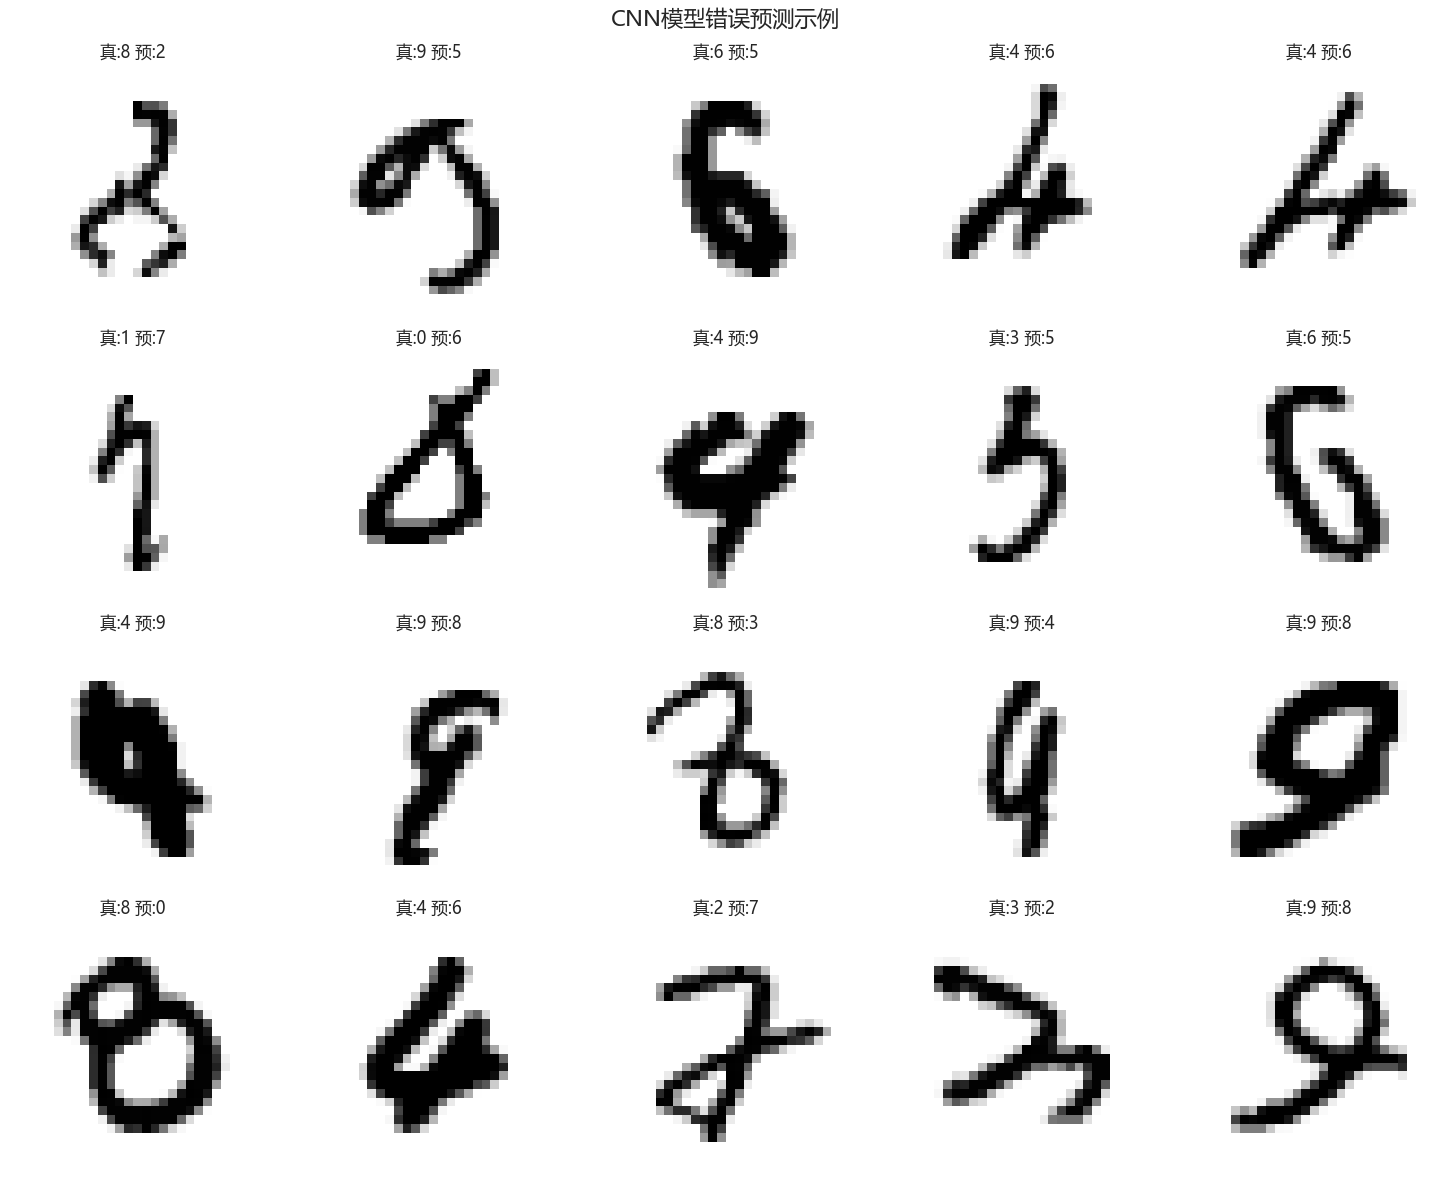

In [11]:
def analyze_errors_deep(model, test_dataset, test_labels, test_preds, n_errors=20):
    """分析深度学习模型的错误样本"""
    # 找到错误预测的索引
    error_indices = np.where(test_labels != test_preds)[0]

    if len(error_indices) == 0:
        print("模型在测试集上没有错误预测！")
        return

    print(f"\nCNN模型在测试集上有 {len(error_indices)} 个错误预测")
    print(f"错误率: {len(error_indices)/len(test_labels):.4f}")

    # 统计常见的错误类型
    from collections import Counter
    error_pairs = [(test_labels[i], test_preds[i]) for i in error_indices]
    error_counter = Counter(error_pairs)

    print("\n最常见的错误类型:")
    for (true, pred), count in error_counter.most_common(5):
        error_rate = count / len(error_indices) * 100
        print(f"  {true} → {pred}: {count}次 ({error_rate:.2f}%)")

    # 可视化一些错误样本
    n_errors_to_show = min(n_errors, len(error_indices))
    error_indices_sample = np.random.choice(error_indices, n_errors_to_show, replace=False)

    # 获取原始图像
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    axes = axes.flatten()

    for i, idx in enumerate(error_indices_sample):
        if i >= len(axes):
            break

        # 获取图像
        image, _ = test_dataset[idx]
        image_np = image.squeeze().cpu().numpy()

        # 显示图像
        axes[i].imshow(image_np, cmap='binary')
        axes[i].set_title(f'真:{test_labels[idx]} 预:{test_preds[idx]}')
        axes[i].axis('off')

    plt.suptitle('CNN模型错误预测示例', fontsize=16)
    plt.tight_layout()
    plt.show()

    return error_indices

# 分析错误样本
error_indices_cnn = analyze_errors_deep(trained_model, test_dataset, test_labels, test_preds, n_errors=20)

第二部分：深度学习的鲁棒性测试

2.1 数据增强函数

In [17]:
def augment_image_torch(image_tensor, augmentation_type, magnitude=0):
    """
    对PyTorch张量进行数据增强
    """
    image_np = image_tensor.squeeze().cpu().numpy()

    if augmentation_type == 'rotate':
        from scipy.ndimage import rotate
        augmented = rotate(image_np, angle=magnitude, reshape=False, mode='nearest', order=1)

    elif augmentation_type == 'scale':
        from scipy.ndimage import zoom
        scaled = zoom(image_np, zoom=magnitude, order=1)

        # 调整回28x28
        h, w = scaled.shape
        if h > 28 and w > 28:
            # 居中裁剪
            start_h, start_w = (h-28)//2, (w-28)//2
            cropped = scaled[start_h:start_h+28, start_w:start_w+28]
        else:
            # 居中填充
            cropped = np.zeros((28, 28))
            start_h, start_w = (28-h)//2, (28-w)//2
            cropped[start_h:start_h+h, start_w:start_w+w] = scaled

        augmented = cropped

    elif augmentation_type == 'noise':
        noise = np.random.normal(0, magnitude, image_np.shape)
        augmented = image_np + noise
        augmented = np.clip(augmented, 0, 1)

    elif augmentation_type == 'translate':
        translated = np.zeros_like(image_np)
        dy, dx = magnitude

        # 计算平移后的位置
        y_start = max(0, dy)
        y_end = min(28, 28 + dy)
        x_start = max(0, dx)
        x_end = min(28, 28 + dx)

        # 源位置
        src_y_start = max(0, -dy)
        src_y_end = min(28, 28 - dy)
        src_x_start = max(0, -dx)
        src_x_end = min(28, 28 - dx)

        translated[y_start:y_end, x_start:x_end] = image_np[src_y_start:src_y_end, src_x_start:src_x_end]
        augmented = translated

    else:
        raise ValueError(f"不支持的增强类型: {augmentation_type}")

    # 转换回张量
    augmented_tensor = torch.FloatTensor(augmented).unsqueeze(0).unsqueeze(0)

    return augmented_tensor

2.2 深度学习模型鲁棒性测试

In [18]:
def test_deep_model_robustness(model, test_dataset, device, n_samples=200):
    """
    测试深度学习模型的鲁棒性
    """
    # 选择测试样本
    sample_indices = np.random.choice(len(test_dataset), n_samples, replace=False)

    # 定义测试条件
    test_conditions = {
        '原始': {'aug_type': None, 'magnitude': 0},
        '旋转_5度': {'aug_type': 'rotate', 'magnitude': 5},
        '旋转_10度': {'aug_type': 'rotate', 'magnitude': 10},
        '旋转_15度': {'aug_type': 'rotate', 'magnitude': 15},
        '缩放_0.9': {'aug_type': 'scale', 'magnitude': 0.9},
        '缩放_1.1': {'aug_type': 'scale', 'magnitude': 1.1},
        '噪声_0.2': {'aug_type': 'noise', 'magnitude': 0.2},
        '平移_2': {'aug_type': 'translate', 'magnitude': (2, 0)},
    }

    results = {}
    all_predictions = {}

    model.eval()

    print("深度学习模型鲁棒性测试:")
    print("="*60)

    for condition_name, condition in test_conditions.items():
        correct = 0
        predictions = []

        with torch.no_grad():
            for idx in tqdm(sample_indices, desc=f"测试 {condition_name}"):
                # 获取原始图像和标签
                image, label = test_dataset[idx]

                if condition['aug_type'] is None:
                    # 原始数据
                    aug_image = image.unsqueeze(0).to(device)
                else:
                    # 应用增强
                    aug_image = augment_image_torch(image, condition['aug_type'], condition['magnitude']).to(device)

                # 预测
                output = model(aug_image)
                _, predicted = output.max(1)

                if predicted.item() == label:
                    correct += 1

                predictions.append(predicted.item())

        accuracy = correct / n_samples
        results[condition_name] = accuracy
        all_predictions[condition_name] = predictions

        print(f"{condition_name}: 准确率 = {accuracy:.4f}")

    return results, all_predictions, sample_indices

# 测试深度学习模型鲁棒性
print("="*50)
print("深度学习CNN模型鲁棒性测试")
print("="*50)
cnn_robustness_results, cnn_predictions, cnn_sample_indices = test_deep_model_robustness(
    trained_model, test_dataset, device, n_samples=200
)

深度学习CNN模型鲁棒性测试
深度学习模型鲁棒性测试:


测试 原始: 100%|██████████| 200/200 [00:00<00:00, 1563.51it/s]


原始: 准确率 = 0.9950


测试 旋转_5度: 100%|██████████| 200/200 [00:00<00:00, 1699.47it/s]


旋转_5度: 准确率 = 0.9900


...

缩放_1.1: 准确率 = 0.9900


测试 噪声_0.2: 100%|██████████| 200/200 [00:00<00:00, 2218.61it/s]


噪声_0.2: 准确率 = 0.9950


测试 平移_2: 100%|██████████| 200/200 [00:00<00:00, 2403.78it/s]

平移_2: 准确率 = 0.9750


2.3 可视化深度学习鲁棒性结果


CNN模型 鲁棒性分析:
  旋转_5度: 准确率下降 0.5%
  旋转_10度: 准确率下降 0.0%
  旋转_15度: 准确率下降 0.5%
  缩放_0.9: 准确率下降 0.0%
  缩放_1.1: 准确率下降 0.5%
  噪声_0.2: 准确率下降 0.0%
  平移_2: 准确率下降 2.0%


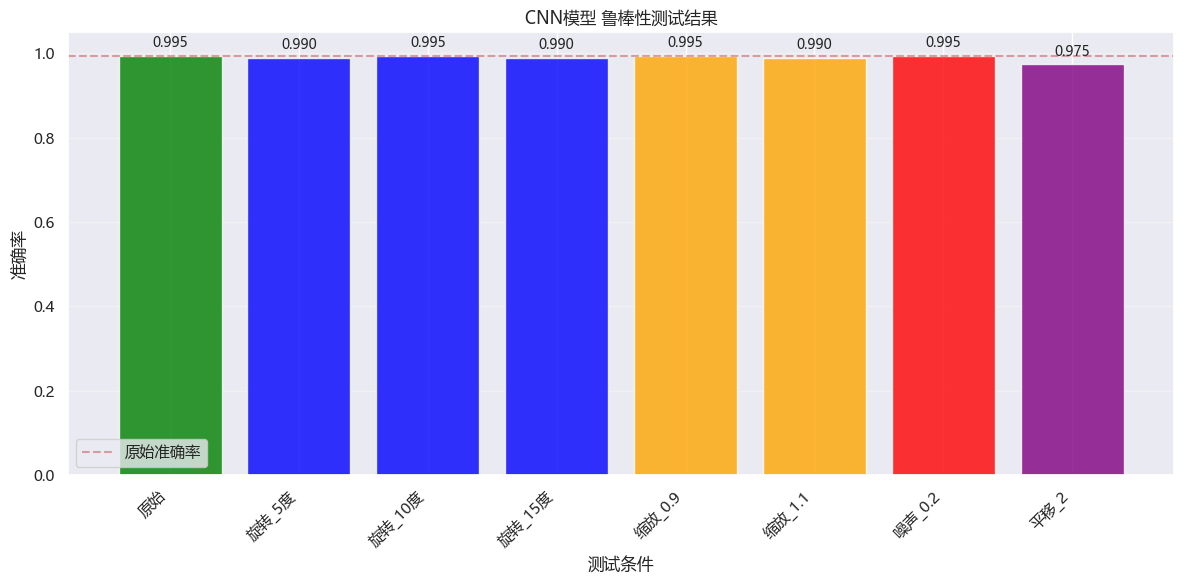

In [19]:
def plot_deep_robustness_results(results, model_name="CNN模型"):
    """
    可视化深度学习模型的鲁棒性结果
    """
    # 准备数据
    condition_names = list(results.keys())
    accuracies = list(results.values())

    # 创建颜色映射
    colors = []
    for name in condition_names:
        if name == '原始':
            colors.append('green')
        elif '旋转' in name:
            colors.append('blue')
        elif '缩放' in name:
            colors.append('orange')
        elif '噪声' in name:
            colors.append('red')
        elif '平移' in name:
            colors.append('purple')
        else:
            colors.append('gray')

    # 绘制柱状图
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(range(len(condition_names)), accuracies, color=colors, alpha=0.8)

    # 添加准确率标签
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
               f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

    ax.set_xlabel('测试条件')
    ax.set_ylabel('准确率')
    ax.set_title(f'{model_name} 鲁棒性测试结果')
    ax.set_xticks(range(len(condition_names)))
    ax.set_xticklabels(condition_names, rotation=45, ha='right')
    ax.set_ylim([0, 1.05])
    ax.axhline(y=results['原始'], color='r', linestyle='--', alpha=0.5, label='原始准确率')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()

    # 计算准确率下降百分比
    print(f"\n{model_name} 鲁棒性分析:")
    original_acc = results['原始']
    for condition_name, acc in results.items():
        if condition_name != '原始':
            drop_percent = (original_acc - acc) / original_acc * 100
            print(f"  {condition_name}: 准确率下降 {drop_percent:.1f}%")

    plt.tight_layout()
    plt.show()

    return condition_names, accuracies

# 可视化深度学习鲁棒性结果
cnn_conditions, cnn_accuracies = plot_deep_robustness_results(cnn_robustness_results, "CNN模型")

保存深度学习模型

In [24]:
import os
import torch
import json
import joblib
from datetime import datetime

def save_deep_learning_model(model, history, config, model_dir='models'):
    """
    保存深度学习模型
    """
    # 创建模型目录
    os.makedirs(model_dir, exist_ok=True)

    # 生成时间戳
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    model_name = f"cnn_mnist_{timestamp}"
    model_path = os.path.join(model_dir, model_name)
    os.makedirs(model_path, exist_ok=True)

    # 保存模型参数
    model_path_pth = os.path.join(model_path, "model.pth")
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': config,
        'training_history': history
    }, model_path_pth)

    # 保存模型结构
    model_script_path = os.path.join(model_path, "model_architecture.txt")
    with open(model_script_path, 'w') as f:
        f.write(str(model))

    # 保存模型配置
    config_path = os.path.join(model_path, "config.json")
    with open(config_path, 'w') as f:
        json.dump(config, f, indent=2)

    # 保存训练历史
    history_path = os.path.join(model_path, "history.json")
    with open(history_path, 'w') as f:
        # 转换numpy类型为Python原生类型
        history_serializable = {}
        for key, value in history.items():
            if isinstance(value, list):
                history_serializable[key] = [float(v) for v in value]
            else:
                history_serializable[key] = float(value)
        json.dump(history_serializable, f, indent=2)

    # 保存模型为TorchScript格式（用于生产部署）
    model_scripted = torch.jit.script(model)
    model_scripted_path = os.path.join(model_path, "model_scripted.pt")
    model_scripted.save(model_scripted_path)

    print(f"深度学习模型已保存到: {model_path}")
    print(f"  模型参数: {model_path_pth}")
    print(f"  模型结构: {model_script_path}")
    print(f"  模型配置: {config_path}")
    print(f"  训练历史: {history_path}")
    print(f"  TorchScript模型: {model_scripted_path}")

    return model_path

# 定义模型配置
model_config = {
    'model_type': 'SimpleCNN',
    'model_params': {
        'dropout_rate': 0.5
    },
    'training_params': {
        'num_epochs': 10,
        'batch_size': 64,
        'learning_rate': 0.001,
        'optimizer': 'Adam',
        'criterion': 'CrossEntropyLoss',
        'scheduler': 'ReduceLROnPlateau'
    },
    'data_params': {
        'train_size': len(train_dataset),
        'val_size': len(val_dataset),
        'test_size': len(test_dataset),
        'normalization': {'mean': 0.1307, 'std': 0.3081}
    },
    'performance': {
        'test_accuracy': test_acc,
        'best_val_accuracy': max(history['val_acc']),
        'final_train_accuracy': history['train_acc'][-1]
    }
}

# 保存深度学习模型
cnn_model_path = save_deep_learning_model(trained_model, history, model_config)

深度学习模型已保存到: models\cnn_mnist_20260413_061144
  模型参数: models\cnn_mnist_20260413_061144\model.pth
  模型结构: models\cnn_mnist_20260413_061144\model_architecture.txt
  模型配置: models\cnn_mnist_20260413_061144\config.json
  训练历史: models\cnn_mnist_20260413_061144\history.json
  TorchScript模型: models\cnn_mnist_20260413_061144\model_scripted.pt
